In [112]:
import re
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
import shap
from scipy.stats import linregress
from tqdm import tqdm
import plotly.graph_objects as go
from datetime import timedelta
from plotly.subplots import make_subplots
import swifter
import plotly.express as px
from itertools import product

In [113]:
# Load dataset
# df = pd.read_csv('shanta_processed_data.csv')
df = pd.read_excel("site_leaching_data.xlsx", sheet_name=0)

# Clean column names: strip whitespace and unify format
def clean_column_name(col):
	col = col.strip()
	col = re.sub(r'\s+', '_', col)
	col = re.sub(r'[^\w\d_]', '', col)
	# Remove double underscores
	col = re.sub(r'__+', '_', col)
	# Convert to lowercase
	col = col.lower()
	# Capitablize first letter and each letter after an underscore
	col = col.replace('_', ' ').title().replace(' ', '_')
	return col

df.columns = [clean_column_name(col) for col in df.columns]

In [ ]:
# Constants for the training & modeling process
random_seed = 13				# random seed for reproducibility
test_sample_size = 0.2			# proportion of data to use for testing
bin_precision = 1				# precision for binning continuous variables

# Cyanide leaching parameters
min_cn_conc = 100 			    # minimum cyanide concentration in ppm
max_cn_conc = 1000 				# maximum cyanide concentration in ppm
do_smoothing_window = 45		# smoothing window in days for dissolved oxygen data

# Set CN bounds
cn_lower_bound = 200  			# lower bound for cyanide concentration in ppm
cn_upper_bound = 500  			# upper bound for cyanide concentration in ppm
penalty_threshold = 450  		# where overdose penalty kicks in
penalty_weight = 0.5     		# USD per excess ppm * t
do_lower_bound = 6.0  			# lower bound for dissolved oxygen in ppm
do_upper_bound = 20.0  			# upper bound for dissolved oxygen in ppm

# Feed charateristics
ultra_fine_sizing = 50	 		# midpoint for < 75 µm sizing
fine_sizing = 112.5				# midpoint for > 75 µm sizing
coarse_sizing = 175 			# midpoint for > 150 µm sizing

# Economic constants
GOLD_PRICE_USD_PER_G = 89.24
NACN_PRICE_USD_PER_KG = 17.0
DO_PRICE_USD_PER_KG = 0.03 	    # USD per kg per tonne
TROY_OZ_TO_G = 31.1035
PPM_TO_KG_PER_T = 1 / 1_000_000 * 1_000  # convert ppm to kg/t
CN_PENALTY_THRESHOLD = 450      # ppm
CN_PENALTY_WEIGHT = 1.0         # USD per ppm per tonne above threshold

## Data Cleansing & Feature Engineering

In [115]:
# --- Calculate CN dosage into leaching circuit ---	
# Fill NaNs with 0 for safe comparison
ppm_tank_1 = df["Cyanide_Profile_Ppm_Leach_Tank_1"].fillna(0).where(
lambda x: (x >= min_cn_conc) & (x <= max_cn_conc), 0
)
ppm_tank_2 = df["Cyanide_Profile_Ppm_Leach_Tank_2"].fillna(0).where(
	lambda x: (x >= min_cn_conc) & (x <= max_cn_conc), 0
)

# Flags indicating which pre-leach tank is receiving CN
df["Leach_Cn_Adds_To_Tank_1"] = ppm_tank_1 > ppm_tank_2
df["Leach_Cn_Adds_To_Tank_2"] = ~df["Leach_Cn_Adds_To_Tank_1"]

# Actual ppm value from the pre-leach tank identified as dosing
df["Leach_Cn_Adds_ppm"] = np.where(df["Leach_Cn_Adds_To_Tank_1"], ppm_tank_1, ppm_tank_2)

# % solids to fractional solids
df["Solids_Fraction"] = df["Percentsolids"] / 100
df["Liquid_Fraction"] = 1 - df["Solids_Fraction"]

# Wet mass of slurry (kg)
df["Slurry_Mass_Kg"] = df["Daily_Milledtreated_Tons"] * 1000 / df["Solids_Fraction"]

# Liquid mass in slurry (assuming water ~1kg/L)
df["Solution_Mass_Kg"] = df["Slurry_Mass_Kg"] * df["Liquid_Fraction"]

df["NaCN_Used_Kg"] = df["Leach_Cn_Adds_ppm"] * df["Solution_Mass_Kg"] / 1e6

df['CN_Kg_T'] = df['NaCN_Used_Kg'] / df['Daily_Milledtreated_Tons']

# --- Clean and impute dissolved oxygen (DO) profile ---
o2_col = "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"

# Replace zero with NaN
df[o2_col] = df[o2_col].replace(0.0, np.nan)

# Impute using a rolling median (or fallback to overall median)
df[o2_col + "_Imputed"] = df[o2_col].fillna(
	df[o2_col].rolling(window=3, min_periods=1, center=True).median()
)

df["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"] = (
	df["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed"]
	.rolling(window=do_smoothing_window, min_periods=1, center=True)
	.mean()
)

# Fallback for any remaining NaNs (start/end of window)
df[o2_col + "_Imputed"] = df[o2_col + "_Imputed"].fillna(df[o2_col].median())

# --- Standardise feed grade and throughput column names ---
df["Leach_Feed_Grade_Au_Gt"] = df["Leach_Feed_Grade_Au_Gt_Day"]

# Standardise particle size fields
df = df.rename(columns={
	"Leach_Feed_Gt_150Μm_Day": "Leach_Feed_Gt_150um_Day",
	"Leach_Feed_Gt_75Μm_Day": "Leach_Feed_Gt_75um_Day",
	"Leach_Feed_Lt_75Μm_Day": "Leach_Feed_Lt_75um_Day"
})

# Ensure datetime is parsed
df["Date"] = pd.to_datetime(df["Date"])


# --- Create Interaction terms ---
size_sum = (
		df["Leach_Feed_Lt_75um_Day"] +
		df["Leach_Feed_Gt_75um_Day"] +
		df["Leach_Feed_Gt_150um_Day"]
	)
df["Fines_Fraction"] = df["Leach_Feed_Lt_75um_Day"] / size_sum.replace(0, np.nan)
df["Grade_x_Fines"] = df["Leach_Feed_Grade_Au_Gt_Day"] * df["Fines_Fraction"]

# Calculate Effective Particle Size (um)
def get_effective_particle_size(row):
	total = (
		row["Leach_Feed_Lt_75um_Day"] +
		row["Leach_Feed_Gt_75um_Day"] +
		row["Leach_Feed_Gt_150um_Day"]
	)
	if total == 0:
		return np.nan
	weighted_d = (
		row["Leach_Feed_Lt_75um_Day"] * ultra_fine_sizing +
		row["Leach_Feed_Gt_75um_Day"] * fine_sizing +
		row["Leach_Feed_Gt_150um_Day"] * coarse_sizing
	) / total
	return weighted_d

df["Effective_Particle_Size_um"] = df.apply(get_effective_particle_size, axis=1)

# Calculate Au Recovery %
df["Actual_Recovery"] = (
	(df["Cil_Feed_Total_Au_Grams"] - df["Total_Au_Tailing_Grams"])
	/ df["Cil_Feed_Total_Au_Grams"]
) * 100

# --- Standardise particle size fields ---
df = df.rename(columns={
	"Cil_Feed_Total_Au_Grams": "Au_Feed_Grams",
	"Total_Au_Tailing_Grams": "Au_Tailings_Grams",
	"Cn_Conc_Tailing_Ppm": "CN_Tailings_Concentration",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth": "Dissolved_Oxygen",
	"Effective_Particle_Size_um": "Particle_Size",
	"Leach_Cn_Adds_ppm": "CN_Concentration",
	"Leach_Feed_Grade_Au_Gt_Day": "Au_Grade",
	"Daily_Milledtreated_Tons": "Tonnes_Processed"
})

In [116]:
features = [
	"Grade_x_Fines",
	"Particle_Size",
	"Dissolved_Oxygen",
	"CN_Concentration",
]

target = "Actual_Recovery"

df_model = df[features + [target]].dropna()
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_sample_size,
													random_state=random_seed)

# Train model
model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1)
model.fit(X, y)

# Predict and evaluate
pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
r2 = model.score(X_test, y_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))

# Print evaluation metrics
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R^2 Score: {r2:.4f}')
print(f'Root Mean Squared Error: {rmse:.2f}')

Mean Absolute Error: 0.41
R^2 Score: 0.9714
Root Mean Squared Error: 0.52


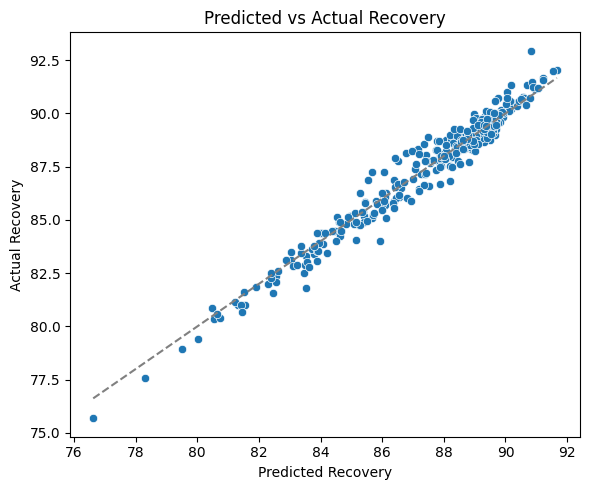

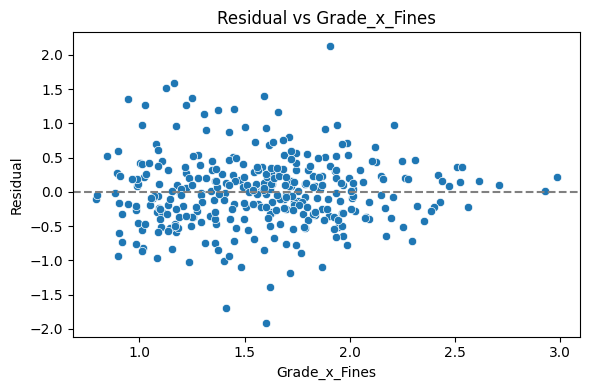

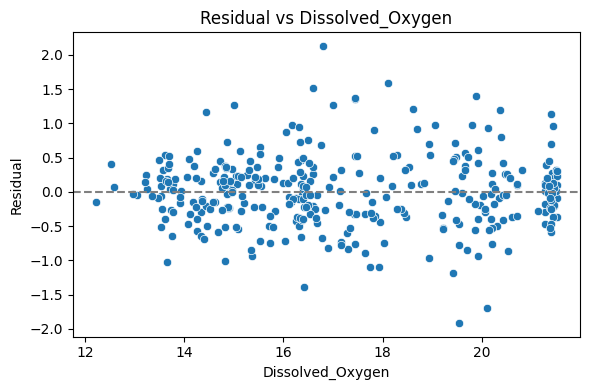

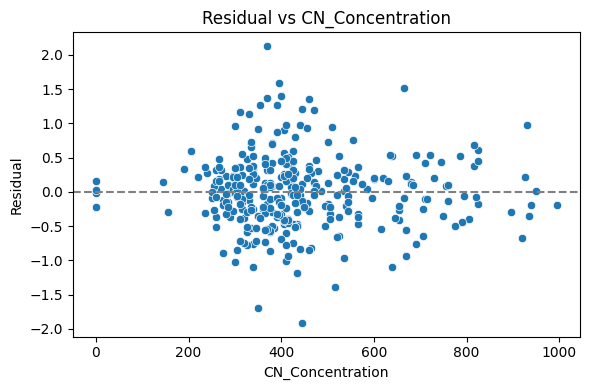

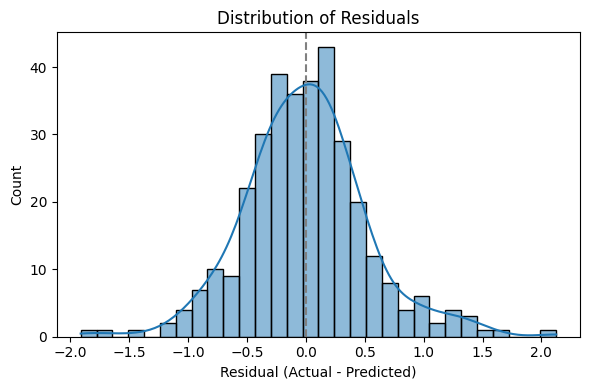

In [117]:
# Predict using trained model
df_model["Predicted_Recovery"] = model.predict(X)
df_model["Residual"] = df_model[target] - df_model["Predicted_Recovery"]

# Plot 1: Actual vs Predicted
plt.figure(figsize=(6, 5))
sns.scatterplot(x="Predicted_Recovery", y=target, data=df_model)
plt.plot([df_model["Predicted_Recovery"].min(), df_model["Predicted_Recovery"].max()],
		 [df_model["Predicted_Recovery"].min(), df_model["Predicted_Recovery"].max()],
		 linestyle='--', color='grey')
plt.xlabel("Predicted Recovery")
plt.ylabel("Actual Recovery")
plt.title("Predicted vs Actual Recovery")
plt.tight_layout()
plt.show()

# Plot 2: Residuals vs Key Features
for col in ["Grade_x_Fines",
			"Dissolved_Oxygen",
			"CN_Concentration"]:
	plt.figure(figsize=(6, 4))
	sns.scatterplot(x=col, y="Residual", data=df_model)
	plt.axhline(0, color='grey', linestyle='--')
	plt.title(f"Residual vs {col}")
	plt.tight_layout()
	plt.show()

# Plot 3: Histogram of residuals
plt.figure(figsize=(6, 4))
sns.histplot(df_model["Residual"], kde=True, bins=30)
plt.axvline(0, color='grey', linestyle='--')
plt.title("Distribution of Residuals")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

# Copy the predicted values and residual to the original DataFrame
df["Predicted_Recovery"] = df_model["Predicted_Recovery"]

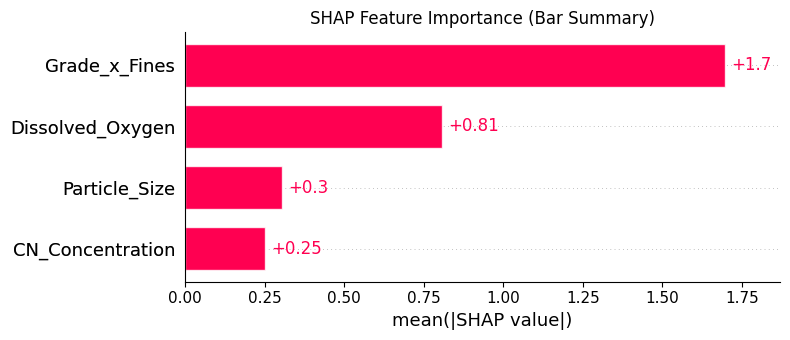

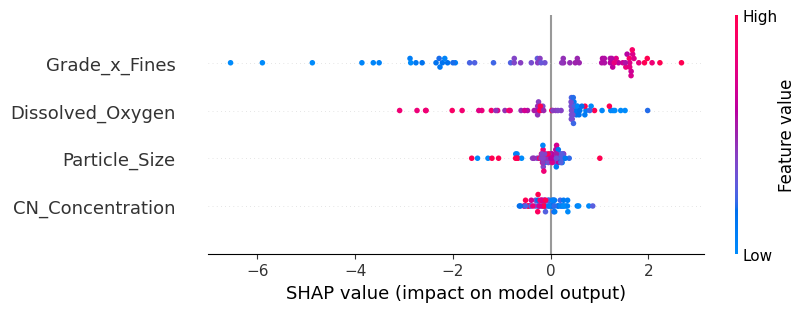

Grade_x_Fines       0.654
Dissolved_Oxygen    0.198
CN_Concentration    0.075
Particle_Size       0.074
dtype: float32

In [118]:
# Create importance Series
feature_importance = pd.Series(
	model.feature_importances_,
	index=features
).sort_values(ascending=False)

# Create SHAP explainer and compute SHAP values
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Plot summary of SHAP values (bar + beeswarm)
plt.figure(figsize=(10, 5))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("SHAP Feature Importance (Bar Summary)")
plt.tight_layout()
plt.show()

# Plot Beeswarm summary for detailed distribution
shap.plots.beeswarm(shap_values, max_display=15)

# Display feature importance to 2 decimal places
feature_importance = feature_importance.round(3)
feature_importance


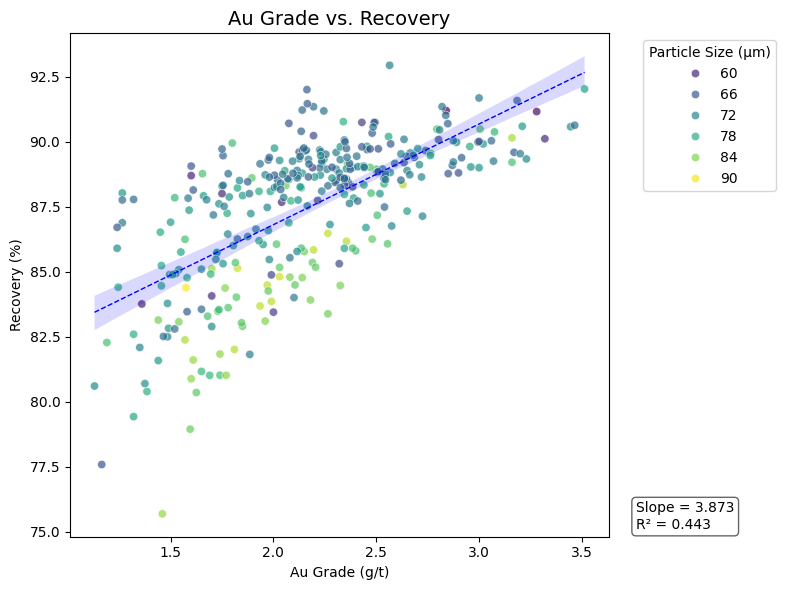

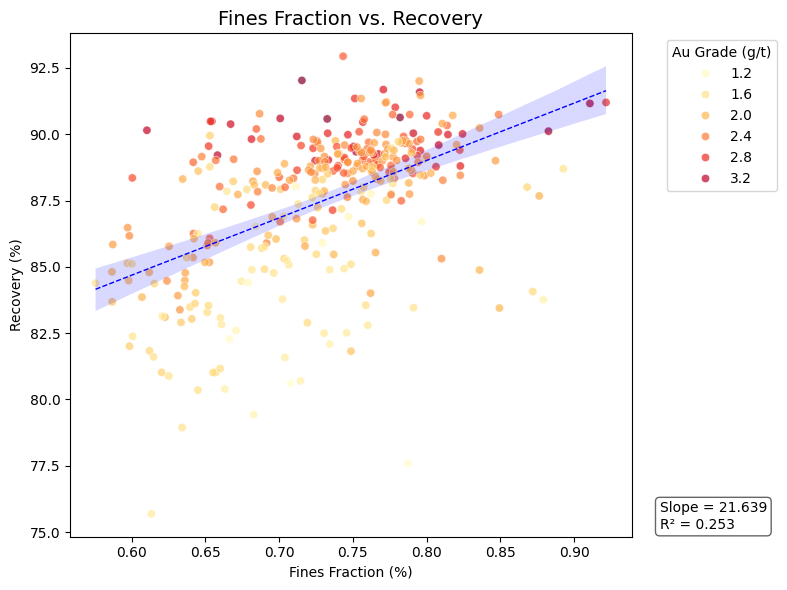

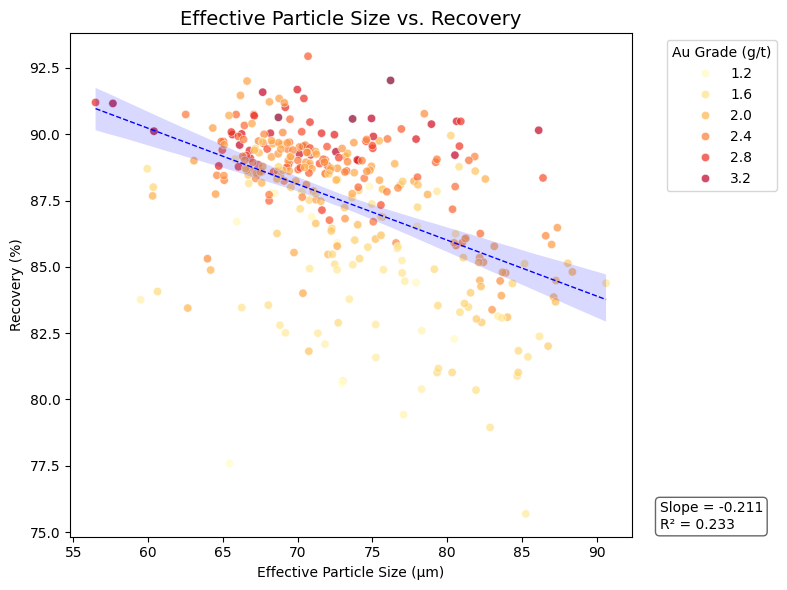

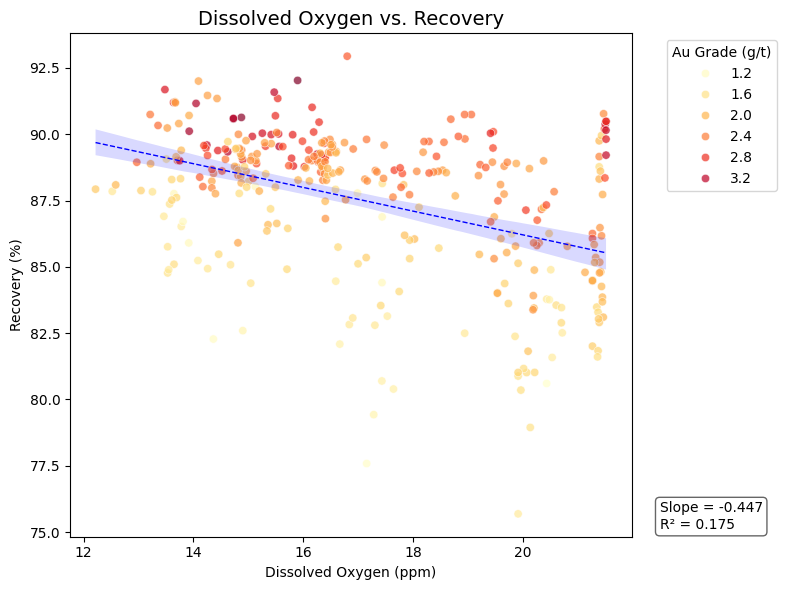

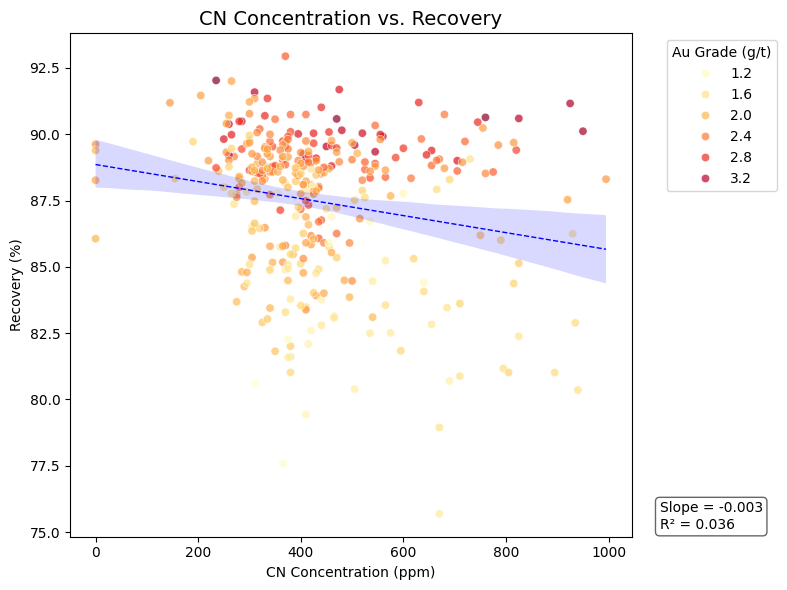

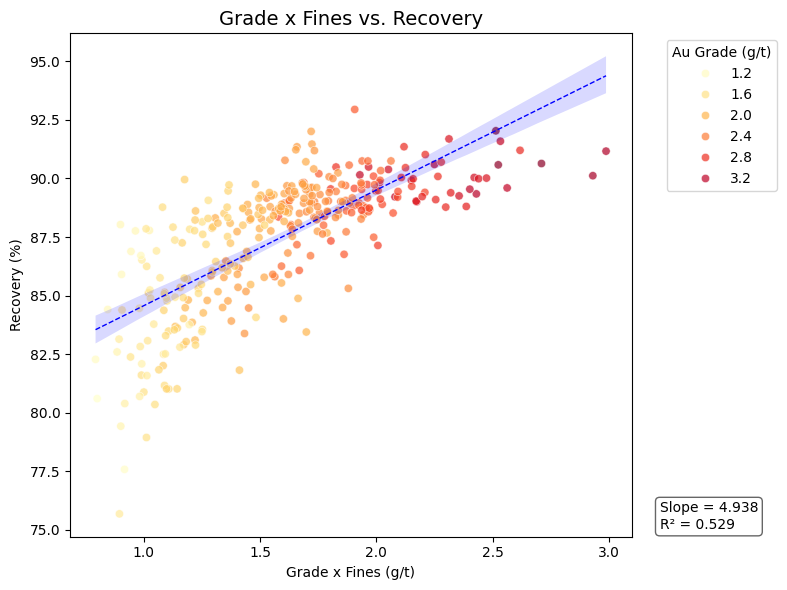

In [119]:
# Plot scatter plot for interaction between Effective Particle Size and Au Recovery

def scatter_plot_trend_hue(df, x_col, y_col, hue_col="Au_Grade", hue_title="Au Grade (g/t)",
						   title: str = "Scatter Plot with Regression Line",
						   xlabel: str = "X", ylabel: str = "Y", palette: str = "YlOrRd"):
	"""
	Plot scatter plot with regression line and show regression slope as a text box.
	"""
	# Calculate regression line
	slope, intercept, r_value, p_value, std_err = linregress(df[x_col], df[y_col])
	reg_text = f"Slope = {slope:.3f}\nR² = {r_value**2:.3f}"

	# Create plot
	plt.figure(figsize=(8, 6))
	sns.scatterplot(x=x_col, y=y_col, data=df,
					hue=hue_col, palette=palette, alpha=0.7)
	sns.regplot(x=x_col, y=y_col, data=df,
				scatter=False, color='blue', line_kws={"linestyle": "--", "linewidth": 1})

	# Add regression info box
	plt.text(1.05, 0.07, reg_text, transform=plt.gca().transAxes,
			 fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round',
													facecolor='white', alpha=0.6))

	# Final plot styling
	plt.title(title, fontsize=14)
	plt.xlabel(xlabel)
	plt.ylabel(ylabel)
	plt.legend(title=hue_title, bbox_to_anchor=(1.05, 1), loc='upper left')
	plt.tight_layout()
	plt.show()


# Call the function to plot Effective Particle Size vs. Recovery
scatter_plot_trend_hue(df, "Au_Grade", target, hue_col="Particle_Size",
					   title="Au Grade vs. Recovery", hue_title="Particle Size (µm)",
					   xlabel="Au Grade (g/t)", ylabel="Recovery (%)", palette="viridis")

scatter_plot_trend_hue(df, "Fines_Fraction", target, hue_col="Au_Grade",
					   title="Fines Fraction vs. Recovery",
					   xlabel="Fines Fraction (%)", ylabel="Recovery (%)")

scatter_plot_trend_hue(df, "Particle_Size", target, hue_col="Au_Grade",
					   title="Effective Particle Size vs. Recovery",
					   xlabel="Effective Particle Size (µm)", ylabel="Recovery (%)")

scatter_plot_trend_hue(df, "Dissolved_Oxygen", target, hue_col="Au_Grade",
					   title="Dissolved Oxygen vs. Recovery",
					   xlabel="Dissolved Oxygen (ppm)", ylabel="Recovery (%)")

scatter_plot_trend_hue(df, "CN_Concentration", target, hue_col="Au_Grade",
					   title="CN Concentration vs. Recovery",
					   xlabel="CN Concentration (ppm)", ylabel="Recovery (%)")

scatter_plot_trend_hue(df, "Grade_x_Fines", target, hue_col="Au_Grade",
					   title="Grade x Fines vs. Recovery",
					   xlabel="Grade x Fines (g/t)", ylabel="Recovery (%)")

## Add Calculated Features

In [120]:
# --- Gold Revenue Calculation ---
df['Actual_Gold_Revenue'] = (
	df['Tonnes_Processed'] * df['Au_Grade'] * df['Actual_Recovery'] / 100 * GOLD_PRICE_USD_PER_G
)

gold_produced = (df['Au_Feed_Grams'] - df['Au_Tailings_Grams'])
df['Alt_Gold_Revenue'] =  gold_produced * GOLD_PRICE_USD_PER_G

# --- Cyanide and Dissolved Oxygen Costs ---
df['Actual_CN_Cost'] = df['NaCN_Used_Kg'] * NACN_PRICE_USD_PER_KG
df['Actual_DO_Cost'] = df['Dissolved_Oxygen'] * df['Solution_Mass_Kg'] / 1e6 * DO_PRICE_USD_PER_KG

# --- Actual Net Value Calculation ---
df['Actual_Net_Value_USD'] = (
	df['Actual_Gold_Revenue'] - df['Actual_CN_Cost'] - df['Actual_DO_Cost']
)

# Display the first 10 rows of the final DataFrame with rounded values
df[['Actual_Gold_Revenue', 'Actual_CN_Cost', 'Actual_DO_Cost', 
	'Actual_Net_Value_USD']].round(2).head(10)

,Actual_Gold_Revenue,Actual_CN_Cost,Actual_DO_Cost,Actual_Net_Value_USD
0,402222.03,2004.13,1.55,400216.35
1,482548.24,1934.01,1.54,480612.69
2,499016.48,1800.52,1.55,497214.41
3,446566.65,2067.03,1.55,444498.06
4,338095.91,1578.86,1.56,336515.49
5,379331.78,1556.51,1.56,377773.71
6,429769.62,1750.41,1.57,428017.65
7,405177.19,1201.97,1.48,403973.73
8,327044.40,1693.58,1.56,325349.26
9,317563.78,1519.05,1.55,316043.18


## Define and test Kinetic Gold Dissolution Equation

In [121]:
def calc_recovery_kinetic(cn_ppm, do_ppm, grade_gpt, particle_size_um,
						  gold_locked_fraction=0.1,
						  k_base=0.005,  # Increased from 0.0012
						  cn_exponent=0.8,
						  do_exponent=0.6,
						  liberation_factor=1.8):  # Stronger liberation sensitivity
	"""
	Returns estimated gold recovery (%) using an adjusted kinetic model.
	"""
	# Prevent unrealistic input values
	cn_ppm = max(cn_ppm, 1)
	do_ppm = max(do_ppm, 0.1)
	particle_size_um = max(particle_size_um, 1)

	# Liberation model (more sensitive)
	liberation = 1 - gold_locked_fraction * np.exp(-liberation_factor * (75 / particle_size_um))

	# Kinetic recovery curve
	k_effective = k_base * (cn_ppm ** cn_exponent) * (do_ppm ** do_exponent)
	recovery_pct = liberation * (1 - np.exp(-k_effective))

	return recovery_pct * 100

# Grab values for testing from first 10 rows of the DataFrame
sample_df = df.head(10).copy()  # Use first 10 rows for testing

for index, row in sample_df.iterrows():
	test_sample = row
	cn = test_sample['CN_Concentration']  # ppm
	do = test_sample['Dissolved_Oxygen']  # ppm
	grade = test_sample['Au_Grade']  # g/t
	particle_size = test_sample['Particle_Size']  # microns
	recovery = calc_recovery_kinetic(cn, do, grade, particle_size)
	print(f"Kinetic Recovery: {recovery:.2f}% vs Actual: {test_sample['Actual_Recovery']:.2f}% "
		  f"Error: {recovery - test_sample['Actual_Recovery']:.2f}%")


Kinetic Recovery: 96.87% vs Actual: 84.49% Error: 12.38%
Kinetic Recovery: 96.73% vs Actual: 86.26% Error: 10.47%
Kinetic Recovery: 96.38% vs Actual: 86.08% Error: 10.30%
Kinetic Recovery: 96.94% vs Actual: 84.47% Error: 12.47%
Kinetic Recovery: 95.29% vs Actual: 82.01% Error: 13.28%
Kinetic Recovery: 95.17% vs Actual: 84.48% Error: 10.68%
Kinetic Recovery: 95.96% vs Actual: 85.84% Error: 10.12%
Kinetic Recovery: 93.41% vs Actual: 85.35% Error: 8.05%
Kinetic Recovery: 96.03% vs Actual: 83.48% Error: 12.55%
Kinetic Recovery: 95.33% vs Actual: 83.29% Error: 12.04%


In [122]:
min_cn_conc = 100 				# minimum cyanide concentration in ppm
max_cn_conc = 500 				# maximum cyanide concentration in ppm
min_do_conc = 13.0 				# minimum dissolved oxygen concentration in ppm
max_do_conc = 17.0 				# maximum dissolved oxygen concentration in ppm

# --- Define grid parameters ---
cn_step = 5  	                # ppm per step
do_step = 1  	                # ppm per step

cn_range = np.linspace(min_cn_conc, max_cn_conc, (int((max_cn_conc - min_cn_conc) / cn_step) + 1))
do_range = np.linspace(min_do_conc, max_do_conc, (int((max_do_conc - min_do_conc) / do_step) + 1))

### Apply Kinetic Model to Dataset

In [123]:
# Define band logic
cn_band_width = 0.15  # ±15%
do_band_width = 0.10  # ±10%

# Placeholder kinetic recovery function
def kinetic_model_recovery(grade_x_fines, particle_size, cn_ppm, do_ppm):
	# A simple tuned kinetic-like model based on prior tuning effort
	base_recovery = 50 + 0.25 * grade_x_fines
	cn_effect = 25 * (1 - np.exp(-0.005 * cn_ppm))
	do_effect = 15 * (1 - np.exp(-0.2 * do_ppm))
	size_penalty = -10 * (particle_size / 150)  # larger size reduces recovery
	return np.clip(base_recovery + cn_effect + do_effect + size_penalty, 0, 100)

# Compute optimal + bands
results = []
for _, row in df.iterrows():
	grade_x_fines = row.get("Grade_x_Fines", np.nan)
	psd = row.get("Particle_Size", np.nan)

	# Define CN and DO range for optimisation
	best_value = -np.inf
	optimal_cn, optimal_do, optimal_recovery = None, None, None

	for cn in cn_range:
		for do in do_range:
			recovery = kinetic_model_recovery(grade_x_fines, psd, cn, do)
			gold_revenue = recovery / 100 * grade_x_fines * GOLD_PRICE_USD_PER_G
			nacn_cost = cn * PPM_TO_KG_PER_T * NACN_PRICE_USD_PER_KG
			do_cost = do * DO_PRICE_USD_PER_KG
			net_value = gold_revenue - nacn_cost - do_cost

			if net_value > best_value:
				best_value = net_value
				optimal_cn, optimal_do = cn, do
				optimal_recovery = recovery

	# Define upper/lower bounds
	cn_low = optimal_cn * (1 - cn_band_width)
	cn_high = optimal_cn * (1 + cn_band_width)
	do_low = optimal_do * (1 - do_band_width)
	do_high = optimal_do * (1 + do_band_width)

	results.append({
		"Optimal_CN_ppm": round(optimal_cn, 1),
		"CN_Low_ppm": round(cn_low, 1),
		"CN_High_ppm": round(cn_high, 1),
		"Optimal_DO_ppm": round(optimal_do, 2),
		"DO_Low_ppm": round(do_low, 2),
		"DO_High_ppm": round(do_high, 2),
		"Predicted_Recovery_pct": round(optimal_recovery, 2),
		"Net_Value_USD_t": round(best_value, 2)
	})

# Merge results into the original DataFrame
df_results = pd.concat([df.reset_index(drop=True), pd.DataFrame(results)], axis=1)

# Add Predicted_Recovery_pct to the original DataFrame
df["Kinetic_Recovery"] = df_results["Predicted_Recovery_pct"]

# Display results
df_results

,Date,Leach_Feed_Throughput_M3Hr,Leach_Feed_Throughput_M3Day,Percentsolids,Leach_Feed_Grade_Au_Gt_Ds,Leach_Feed_Grade_Au_Gt_Ns,Au_Grade,Leach_Feed_Grade_Ag_Gt_Ds,Leach_Feed_Grade_Ag_Gt_Ns,Leach_Feed_Grade_Ag_Gt_Day,...,Actual_DO_Cost,Actual_Net_Value_USD,Optimal_CN_ppm,CN_Low_ppm,CN_High_ppm,Optimal_DO_ppm,DO_Low_ppm,DO_High_ppm,Predicted_Recovery_pct,Net_Value_USD_t
0,2024-06-01,140.387445,3369.298687,51.041667,2.08,2.13,2.105,7.80,5.99,6.895,...,1.551327,400216.345680,500.0,425.0,575.0,17.0,15.3,18.7,82.30,96.99
1,2024-06-02,139.864505,3356.748120,51.083333,2.43,2.53,2.480,6.93,6.98,6.955,...,1.544830,480612.686470,500.0,425.0,575.0,17.0,15.3,18.7,82.36,115.66
2,2024-06-03,140.687229,3376.493498,51.083333,2.28,2.83,2.555,5.22,5.31,5.265,...,1.553918,497214.409731,500.0,425.0,575.0,17.0,15.3,18.7,82.45,121.39
3,2024-06-04,140.645957,3375.502965,51.166667,2.19,2.46,2.325,5.57,7.01,6.290,...,1.552016,444498.064856,500.0,425.0,575.0,17.0,15.3,18.7,82.24,105.12
4,2024-06-05,141.223079,3389.353889,51.083333,2.07,1.55,1.810,5.15,4.97,5.060,...,1.559836,336515.489316,500.0,425.0,575.0,17.0,15.3,18.7,81.93,77.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,2025-04-26,122.855679,2897.346439,50.217391,2.22,2.27,2.245,4.95,4.55,4.750,...,0.865048,388192.596470,500.0,425.0,575.0,17.0,15.3,18.7,83.27,127.47
330,2025-04-27,139.610423,3350.650146,51.083333,2.21,1.66,1.935,4.19,3.52,3.855,...,0.991893,386936.444768,500.0,425.0,575.0,17.0,15.3,18.7,83.19,109.57
331,2025-04-28,137.809928,3307.438263,51.333333,2.45,1.82,2.135,4.68,4.38,4.530,...,0.979856,431068.527089,500.0,425.0,575.0,17.0,15.3,18.7,83.42,127.47
332,2025-04-29,138.107144,3314.571458,51.541667,1.51,2.00,1.755,4.19,4.12,4.155,...,0.981918,349234.148547,500.0,425.0,575.0,17.0,15.3,18.7,83.21,99.72


XGB -> R²: 0.9670, RMSE: 0.52, MAE: 0.39
Kinetic Model -> R²: 0.3327, RMSE: 5.15, MAE: 4.72


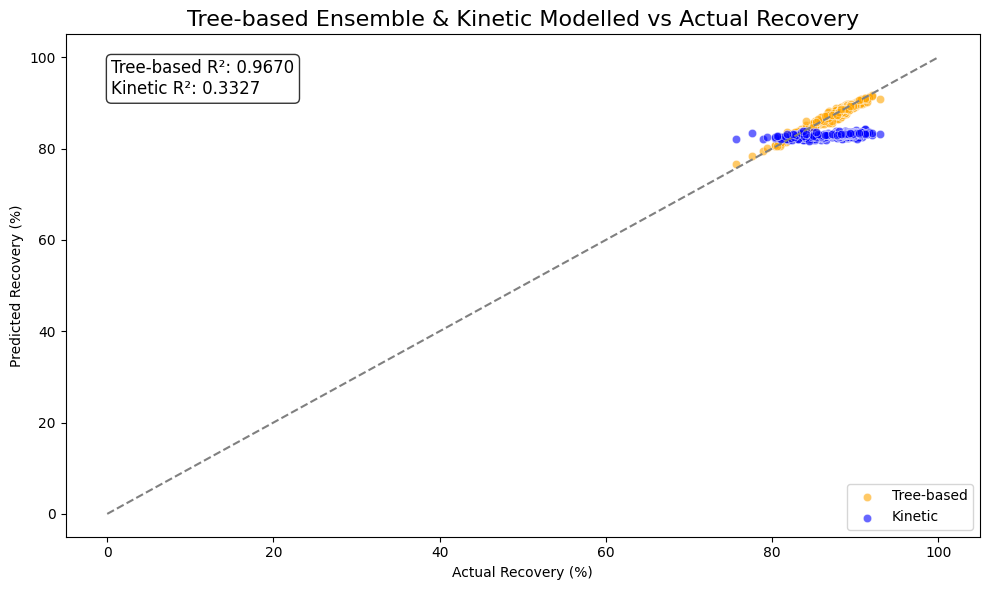

In [124]:
def evaluate_model(true, pred, label):
	# Calculate R²
	r2 = np.corrcoef(true, pred)[0, 1] ** 2
	rmse = np.sqrt(mean_squared_error(true, pred))
	mae = mean_absolute_error(true, pred)
	print(f"{label} -> R²: {r2:.4f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}")

evaluate_model(df["Actual_Recovery"], df["Predicted_Recovery"], "XGB")
evaluate_model(df["Actual_Recovery"], df["Kinetic_Recovery"], "Kinetic Model")

# Plot predicted vs actual recovery for both models
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Actual_Recovery", y="Predicted_Recovery", data=df,
				label="Tree-based", color="orange", alpha=0.6)
sns.scatterplot(x="Actual_Recovery", y="Kinetic_Recovery", data=df,
				label="Kinetic", color="blue", alpha=0.6)
plt.plot([0, 100], [0, 100], linestyle="--", color="gray")
plt.xlabel("Actual Recovery (%)")
plt.ylabel("Predicted Recovery (%)")
plt.title("Tree-based Ensemble & Kinetic Modelled vs Actual Recovery", fontsize=16)
plt.legend()
plt.grid(False)
# Add performance metrics to the plot
plt.text(0.05, 0.95, f"Tree-based R²: {np.corrcoef(df['Actual_Recovery'],
			df['Predicted_Recovery'])[0, 1]**2:.4f}\n"
			f"Kinetic R²: {np.corrcoef(df['Actual_Recovery'], df['Kinetic_Recovery'])[0, 1]**2:.4f}",
			transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
			bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()

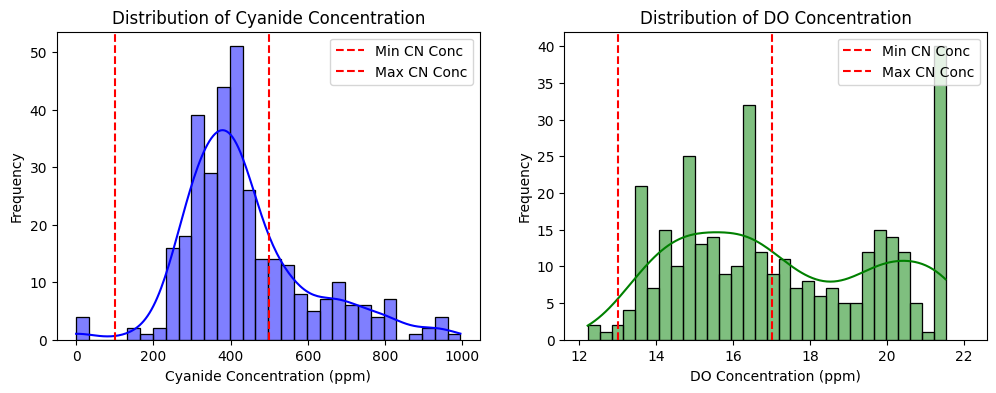

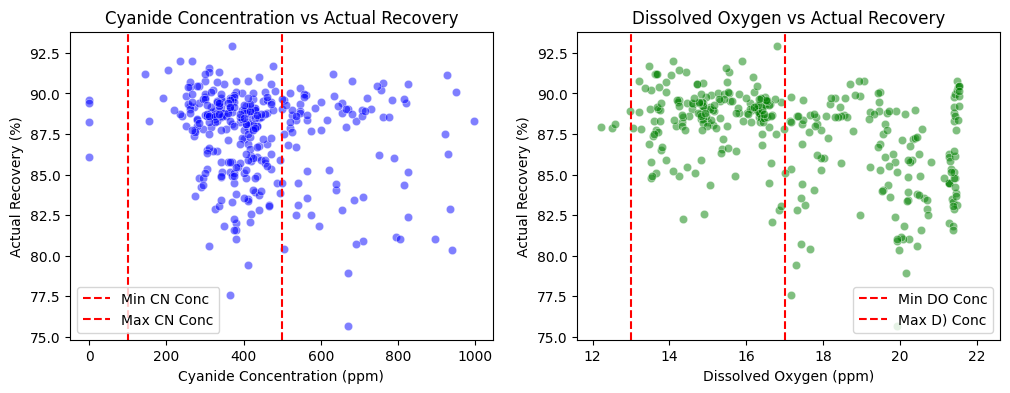

In [125]:
# Plot subplot distributions of CN Concentration and DO Concentration
plt.figure(figsize=(12, 4))

# Plot distribution of CN Concentration
plt.subplot(1, 2, 1)
sns.histplot(df['CN_Concentration'], bins=30, kde=True, color='blue')
plt.title("Distribution of Cyanide Concentration")
plt.xlabel("Cyanide Concentration (ppm)")
plt.ylabel("Frequency")
plt.axvline(min_cn_conc, color='red', linestyle='--', label='Min CN Conc')
plt.axvline(max_cn_conc, color='red', linestyle='--', label='Max CN Conc')
plt.legend()

# Plot distribution of DO Concentration
plt.subplot(1, 2, 2)
sns.histplot(df['Dissolved_Oxygen'], bins=30, kde=True, color='green')
plt.title("Distribution of DO Concentration")
plt.xlabel("DO Concentration (ppm)")
# Set min/max axis limits
plt.xlim(df['Dissolved_Oxygen'].min() * 0.95, df['Dissolved_Oxygen'].max() * 1.05)
plt.ylabel("Frequency")
plt.axvline(min_do_conc, color='red', linestyle='--', label='Min CN Conc')
plt.axvline(max_do_conc, color='red', linestyle='--', label='Max CN Conc')
plt.legend()
plt.show()

# Plot distribution of CN Concentration with Recoveries
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.scatterplot(x='CN_Concentration', y='Actual_Recovery', data=df, alpha=0.5, color='blue')
plt.axvline(min_cn_conc, color='red', linestyle='--', label='Min CN Conc')
plt.axvline(max_cn_conc, color='red', linestyle='--', label='Max CN Conc')
plt.title("Cyanide Concentration vs Actual Recovery")
plt.xlabel("Cyanide Concentration (ppm)")
plt.ylabel("Actual Recovery (%)")
plt.legend()

plt.subplot(1, 2, 2)
sns.scatterplot(x='Dissolved_Oxygen', y='Actual_Recovery', data=df, alpha=0.5, color='green')
plt.axvline(min_do_conc, color='red', linestyle='--', label='Min DO Conc')
plt.axvline(max_do_conc, color='red', linestyle='--', label='Max D) Conc')
plt.title("Dissolved Oxygen vs Actual Recovery")
plt.xlabel("Dissolved Oxygen (ppm)")
plt.xlim(df['Dissolved_Oxygen'].min() * 0.95, df['Dissolved_Oxygen'].max() * 1.05)
plt.ylabel("Actual Recovery (%)")
plt.legend(loc='lower right')

plt.show()

In [126]:
# Function to simulate band recommendations using model
def calculate_optimal_band(row, model, cn_range, do_range):
	# Inputs from row
	grade_fines = row["Grade_x_Fines"]
	psd = row["Particle_Size"]
	solids_fraction = row["Percentsolids"] / 100
	liquid_fraction = 1 - solids_fraction

	# Slurry mass per tonne of ore (kg)
	slurry_mass_kg = 1000 / solids_fraction

	# Solution mass per tonne of ore (kg)
	solution_mass_kg = slurry_mass_kg * liquid_fraction

	best_value = -np.inf
	best_cn, best_do, best_recovery = np.nan, np.nan, np.nan

	band_results = []

	for cn in cn_range:
		for do in do_range:
			# Simulate input
			X_sim = pd.DataFrame([{
				"Grade_x_Fines": grade_fines,
				"Particle_Size": psd,
				"Dissolved_Oxygen": do,
				"CN_Concentration": cn,
			}])

			recovery = model.predict(X_sim)[0]

			# --- Revenue from recovery ---
			gold_recovered_g = recovery * row["Au_Grade"] / 100
			gold_revenue = gold_recovered_g * GOLD_PRICE_USD_PER_G

			# --- Cyanide cost (per tonne of ore) ---
			nacn_used_kg = cn * solution_mass_kg / 1e6
			cn_cost = nacn_used_kg * NACN_PRICE_USD_PER_KG

			# --- DO cost (per tonne of ore) ---
			do_used_kg = do * solution_mass_kg / 1e6
			do_cost = do_used_kg * DO_PRICE_USD_PER_KG

			# --- Penalty logic ---
			cn_penalty = CN_PENALTY_WEIGHT * max(0, cn - CN_PENALTY_THRESHOLD)

			total_cost = cn_cost + do_cost + cn_penalty
			net = gold_revenue - total_cost

			band_results.append((cn, do, recovery, net))

			if net > best_value:
				best_value = net
				best_cn, best_do, best_recovery = cn, do, recovery

	df_band = pd.DataFrame(band_results, columns=["CN", "DO", "Recovery", "NetValue"])
	top_band = df_band[df_band["NetValue"] >= 0.98 * best_value]

	return pd.Series({
		"CN_Recommended_Low": top_band["CN"].min(),
		"CN_Recommended_High": top_band["CN"].max(),
		"DO_Recommended_Low": top_band["DO"].min(),
		"DO_Recommended_High": top_band["DO"].max(),
		"Optimal_CN": best_cn,
		"Optimal_DO": best_do,
		"Optimal_Recovery": best_recovery,
		"Optimal_Net_Value_USD_t": best_value,
	})



# Apply row-wise simulation
recommendations = df.apply(lambda row: calculate_optimal_band(row, model, cn_range, do_range), axis=1)
df = pd.concat([df.reset_index(drop=True), recommendations.reset_index(drop=True)], axis=1)

df[["CN_Recommended_Low",
		"CN_Recommended_High",
		"DO_Recommended_Low",
		"DO_Recommended_High",
		"Optimal_CN",
		"Optimal_DO",
		"Optimal_Recovery",
		"Optimal_Net_Value_USD_t"]].head()

# Save the dataFrame with optimal recommendations to CSV
df.to_csv("df_with_optimal_recommendations.csv", index=False)

In [127]:
# Define axis values
dates = df["Date"]
cn_actual = df["CN_Concentration"]
cn_low = df["CN_Recommended_Low"]
cn_high = df["CN_Recommended_High"]
do_actual = df["Dissolved_Oxygen"]
do_low = df["DO_Recommended_Low"]
do_high = df["DO_Recommended_High"]
net_value = df.get("Net_Value_USD_t", pd.Series([None] * len(df)))

# Create custom hover text
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Start with the required fields
hover_text = (
	"Date: " + df["Date"].dt.strftime("%Y-%m-%d") +
	"<br>CN Actual: " + cn_actual.round(1).astype(str) + " ppm" +
	"<br>CN Range: " + cn_low.round(1).astype(str) + " - " + cn_high.round(1).astype(str) +
	"<br>DO Actual: " + do_actual.round(1).astype(str) + " ppm" +
	"<br>DO Range: " + do_low.round(1).astype(str) + " - " + do_high.round(1).astype(str)
)

# Now append Net Value safely row-by-row (not as a string append)
if "Net_Value_USD_t" in df.columns:
	hover_text += "<br>Net Value: $" + df["Net_Value_USD_t"].round(2).astype(str)

# Build figure
fig = go.Figure()

# CN actual
fig.add_trace(go.Scatter(
	x=dates, y=cn_actual, mode="lines", name="CN Actual",
	line=dict(color="black"), hovertext=hover_text, hoverinfo="text"
))

# CN shaded band
fig.add_trace(go.Scatter(
	x=dates.tolist() + dates[::-1].tolist(),
	y=cn_high.tolist() + cn_low[::-1].tolist(),
	fill='toself',
	fillcolor='rgba(100,100,100,0.15)',
	line=dict(color='rgba(255,255,255,0)'),
	name='CN Recommended Range',
	hoverinfo="skip"
))

# DO actual
fig.add_trace(go.Scatter(
	x=dates, y=do_actual, mode="lines", name="DO Actual",
	line=dict(color="blue", dash="dot"), yaxis="y2",
	hovertext=hover_text, hoverinfo="text"
))

# DO shaded band
fig.add_trace(go.Scatter(
	x=dates.tolist() + dates[::-1].tolist(),
	y=do_high.tolist() + do_low[::-1].tolist(),
	fill='toself',
	fillcolor='rgba(135,206,250,0.25)',
	line=dict(color='rgba(255,255,255,0)'),
	name='DO Recommended Range',
	hoverinfo="skip",
	yaxis="y2"
))

# Add threshold overlays (e.g. static overdose)
fig.add_hline(y=cn_upper_bound, line_dash="dot", line_color="red",
			  annotation_text="CN Overdose Threshold", annotation_position="top left")
fig.add_hline(y=do_lower_bound, line_dash="dot", line_color="blue",
			  annotation_text="Low DO Threshold", annotation_position="bottom left", yref="y2")

# Layout
fig.update_layout(
	plot_bgcolor="white",		# use rgba(0,0,0,0) for transparent background
	paper_bgcolor="white",
	title=dict(
		text="CN & DO Actual vs Recommended Ranges",
		font=dict(size=20),
		x=0.5, y=0.95, xanchor="center", yanchor="top"
		),
	xaxis_title="Date",
	yaxis=dict(title="Cyanide (ppm)"),
	yaxis2=dict(title="Dissolved Oxygen (ppm)", overlaying="y", side="right"),
	legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
	margin=dict(t=80),
	height=550
)

fig.show()

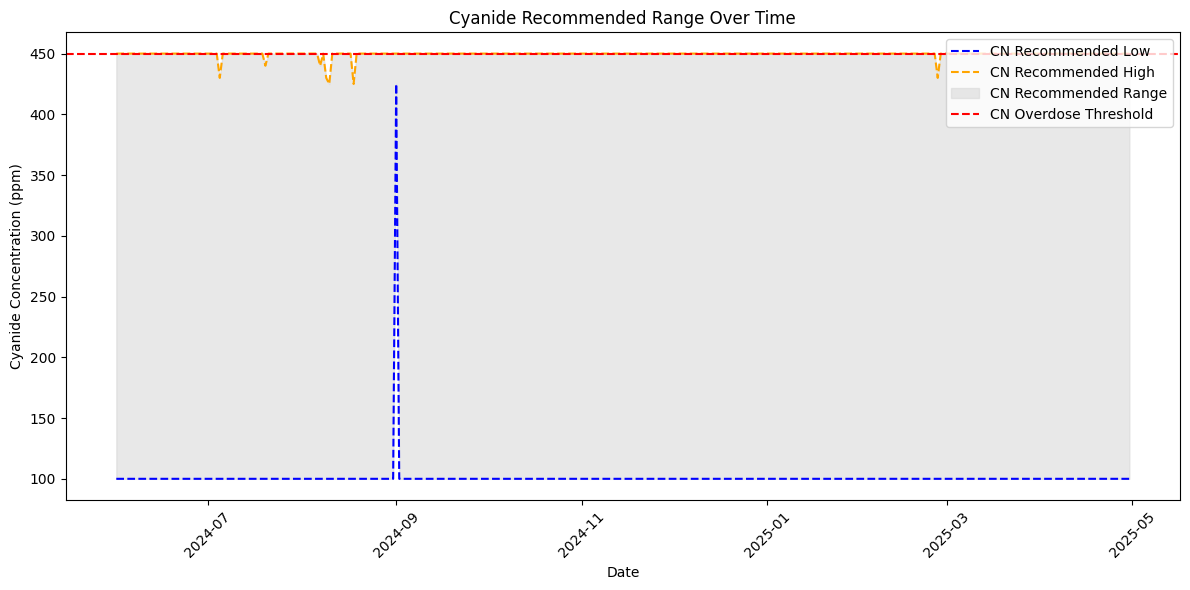

In [128]:
# Plot CN Recommended Range over time
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["CN_Recommended_Low"], label="CN Recommended Low", color="blue", linestyle="--")
plt.plot(df["Date"], df["CN_Recommended_High"], label="CN Recommended High", color="orange", linestyle="--")
plt.fill_between(df["Date"], df["CN_Recommended_Low"], df["CN_Recommended_High"],
				 color="lightgray", alpha=0.5, label="CN Recommended Range")	
plt.axhline(y=450, color='red', linestyle='--', label="CN Overdose Threshold")
plt.title("Cyanide Recommended Range Over Time")
plt.xlabel("Date")
plt.ylabel("Cyanide Concentration (ppm)")
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

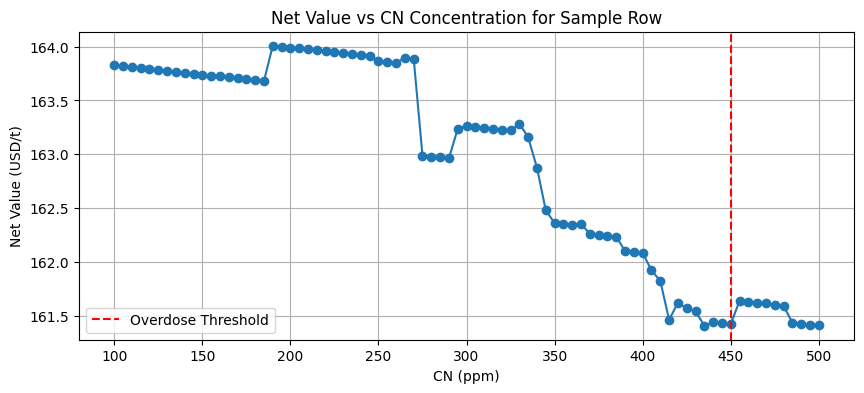

In [129]:
test_row = df.iloc[0]

net_values = []
for cn in cn_range:
	row_values = []
	for do in do_range:
		X_sim = pd.DataFrame([{
			"Grade_x_Fines": test_row["Grade_x_Fines"],
			"Particle_Size": test_row["Particle_Size"],
			"Dissolved_Oxygen": do,
			"CN_Concentration": cn
		}])
		recovery = model.predict(X_sim)[0]
		revenue = (
			recovery / 100 * test_row["Au_Grade"] * GOLD_PRICE_USD_PER_G
		)
		cn_cost = cn * NACN_PRICE_USD_PER_KG / 1000
		do_cost = do * DO_PRICE_USD_PER_KG
		net = revenue - cn_cost - do_cost
		row_values.append(net)
	net_values.append(max(row_values))  # best DO for this CN

plt.figure(figsize=(10, 4))
plt.plot(cn_range, net_values, marker='o')
plt.title("Net Value vs CN Concentration for Sample Row")
plt.xlabel("CN (ppm)")
plt.ylabel("Net Value (USD/t)")
plt.grid(True)
plt.axvline(450, color='red', linestyle='--', label='Overdose Threshold')
plt.legend()
plt.show()


In [130]:
# --- Define the plotting function ---
def plot_cn_do_actuals(df_window, cn_upper_bound=cn_upper_bound, band_type="CN"):
	# Extract fields
	cn_actual = df_window["CN_Concentration"]
	do_actual = df_window["Dissolved_Oxygen"]
	cn_low = df_window["CN_Recommended_Low"]
	cn_high = df_window["CN_Recommended_High"]
	do_low = df_window["DO_Recommended_Low"]
	do_high = df_window["DO_Recommended_High"]
	net_value = df_window["Actual_Net_Value_USD"] / df_window["Tonnes_Processed"] 
	value_delta = df_window["Optimal_Net_Value_USD_t"] - net_value
	dates = df_window["Date"]

	hover_text = (
		"Date: " + df_window["Date"].dt.strftime("%Y-%m-%d") +
		"<br>CN Actual: " + cn_actual.round(1).astype(str) + " ppm" +
		"<br>CN Range: " + cn_low.round(1).astype(str) + " - " + cn_high.round(1).astype(str) +
		"<br>DO Actual: " + do_actual.round(1).astype(str) + " ppm" +
		"<br>DO Range: " + do_low.round(1).astype(str) + " - " + do_high.round(1).astype(str) +
		"<br>Net Value Δ: $" + value_delta.round(2).astype(str)
	)

	fig = go.Figure()

	# CN actual
	fig.add_trace(go.Scatter(
		x=dates, y=cn_actual, name="CN Actual",
		mode="lines", line=dict(color="black"),
		hovertext=hover_text, hoverinfo="text", yaxis="y"
	))

	# CN or DO Band
	if band_type == "CN":
		fig.add_trace(go.Scatter(
			x=dates.tolist() + dates[::-1].tolist(),
			y=cn_high.tolist() + cn_low[::-1].tolist(),
			fill="toself", fillcolor="rgba(100,100,100,0.15)",
			line=dict(color="rgba(255,255,255,0)"),
			name="CN Recommended Range", yaxis="y", showlegend=True
		))
	elif band_type == "DO":
		fig.add_trace(go.Scatter(
			x=dates.tolist() + dates[::-1].tolist(),
			y=do_high.tolist() + do_low[::-1].tolist(),
			fill="toself", fillcolor="rgba(135,206,250,0.2)",
			line=dict(color="rgba(255,255,255,0)"),
			name="DO Recommended Range", yaxis="y2", showlegend=True
		))

	# --- Compute axis limits (±10% margin) ---
	# CN axis range (include both actual and band limits)
	cn_all = pd.concat([cn_actual, cn_low, cn_high])
	cn_min, cn_max = cn_all.min(), cn_all.max()
	cn_margin = 0.10 * (cn_max - cn_min)
	cn_axis_min = cn_min - cn_margin
	cn_axis_max = cn_max + cn_margin

	# DO axis range (include both actual and band limits)
	do_all = pd.concat([do_actual, do_low, do_high])
	do_min, do_max = do_all.min(), do_all.max()
	do_margin = 0.10 * (do_max - do_min)
	do_axis_min = do_min - do_margin
	do_axis_max = do_max + do_margin

	fig.add_trace(go.Scatter(
		x=dates, y=do_actual, name="DO Actual",
		mode="lines", line=dict(color="blue", dash="dot"),
		hoverinfo="skip", yaxis="y2"
	))

	# Thresholds
	fig.add_hline(y=cn_upper_bound, line=dict(color="red", width=1, dash="dash"),
				  annotation_text="CN Overdose Threshold", annotation_position="top left")
	fig.add_hline(y=9.0, line=dict(color="blue", width=1, dash="dot"),
				  annotation_text="Low DO Threshold", annotation_position="top right", yref="y2")

	# Layout
	fig.update_layout(
		title=dict(
			text=f'CN and DO Actuals vs Recommendations ({band_type} Band)',
			font=dict(size=20),
			x=0.5, y=0.95, xanchor="center", yanchor="top"
		),
		plot_bgcolor='white',
		paper_bgcolor='white',
		template='plotly_white',
		xaxis=dict(title='Date'),
		yaxis=dict(
			title='Cyanide (ppm)',
			showgrid=False,
			gridcolor='lightgrey',
			range=[cn_axis_min, cn_axis_max]
		),
		yaxis2=dict(
			title='Dissolved Oxygen (ppm)',
			overlaying='y',
			side='right',
			showgrid=False,
			range=[do_axis_min, do_axis_max]
		),
		legend=dict(
			orientation='h',
			yanchor='top',
			y=1.15,               
			xanchor='center',
			x=0.5,
			font=dict(size=12)
		),
	)

	return fig


# --- Define window ---
start_date = pd.to_datetime("2024-09-15")
window_days = 14
end_date = start_date + timedelta(days=window_days)

# --- Filter ---
df_window = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)].copy()

# --- Show CN-band plot ---
fig_cn = plot_cn_do_actuals(df_window, band_type="CN")
fig_cn.show()

# --- Show DO-band plot ---
fig_do = plot_cn_do_actuals(df_window, band_type="DO")
fig_do.show()

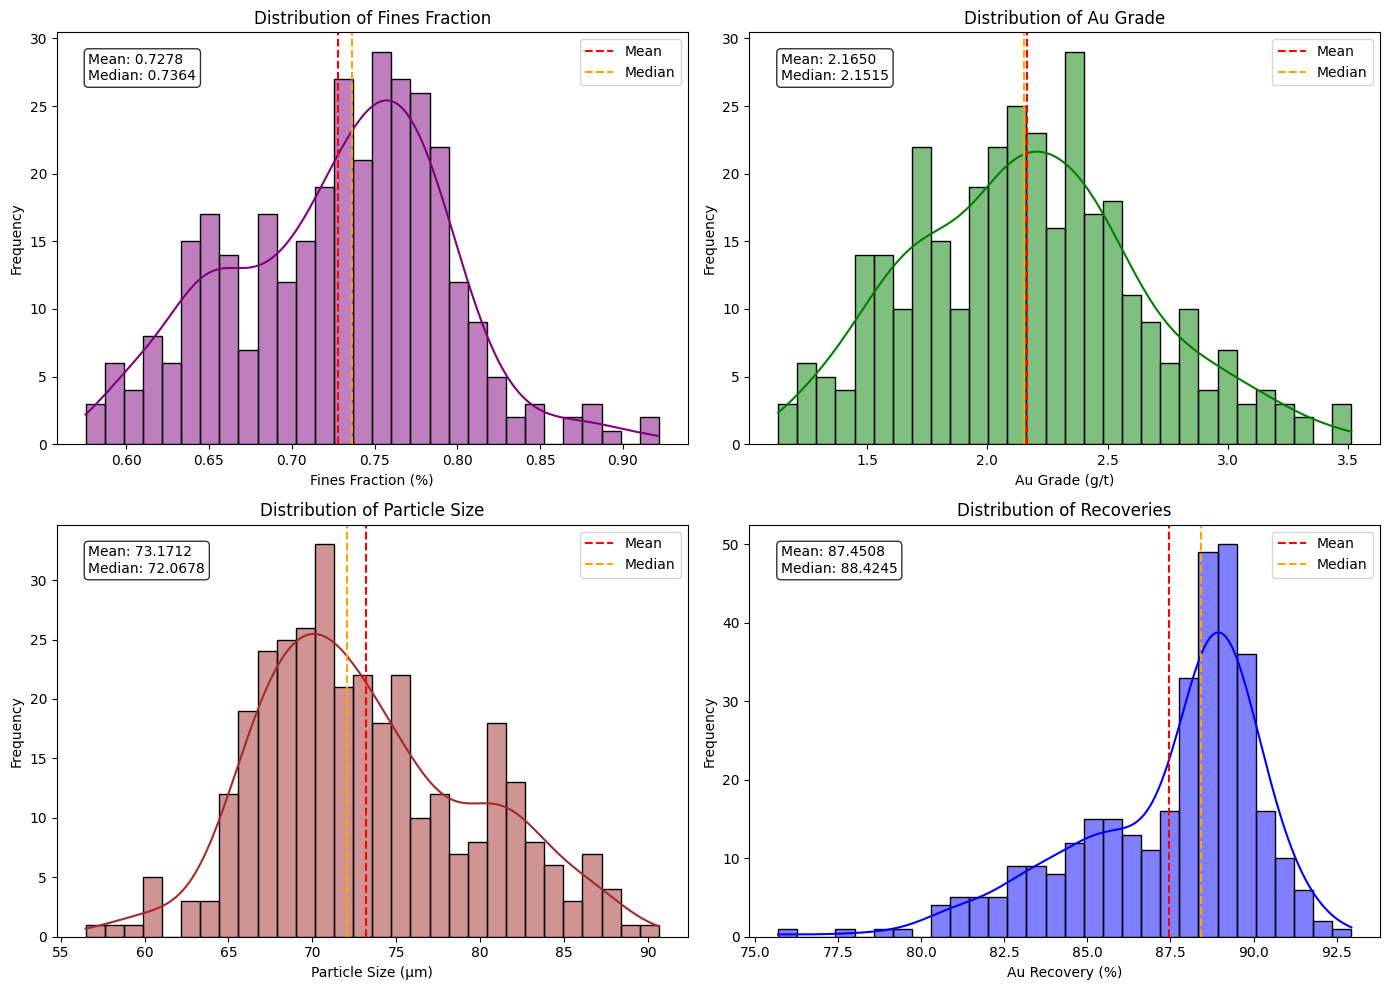

In [131]:
# --- Reusable distribution plot function ---
def plot_distribution(ax, data, column, title, xlabel, color="blue"):
	"""
	Plots a histogram with KDE, mean/median lines, and annotation on a given matplotlib Axes.
	"""
	# Plot histogram with KDE
	sns.histplot(data[column], bins=30, kde=True, color=color, ax=ax)

	# Titles and labels
	ax.set_title(title)
	ax.set_xlabel(xlabel)
	ax.set_ylabel("Frequency")

	# Mean and median
	mean_val = data[column].mean()
	median_val = data[column].median()
	ax.axvline(mean_val, color='red', linestyle='--', label='Mean')
	ax.axvline(median_val, color='orange', linestyle='--', label='Median')

	# Text annotation
	ax.text(0.05, 0.95,
			f"Mean: {mean_val:.4f}\nMedian: {median_val:.4f}",
			transform=ax.transAxes,
			fontsize=10,
			verticalalignment='top',
			bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

	ax.legend()


# --- Create 2x2 subplot grid ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# --- Define plot configs ---
plot_configs = [
	{
		"column": "Fines_Fraction",
		"color": "purple",
		"title": "Distribution of Fines Fraction",
		"xlabel": "Fines Fraction (%)"
	},
	{
		"column": "Au_Grade",
		"color": "green",
		"title": "Distribution of Au Grade",
		"xlabel": "Au Grade (g/t)"
	},
	{
		"column": "Particle_Size",
		"color": "brown",
		"title": "Distribution of Particle Size",
		"xlabel": "Particle Size (µm)"
	},
	{
		"column": "Actual_Recovery",
		"color": "blue",
		"title": "Distribution of Recoveries",
		"xlabel": "Au Recovery (%)"
	}
]

# --- Plot each using the reusable function ---
for ax, cfg in zip(axes, plot_configs):
	plot_distribution(
		ax=ax,
		data=df,
		column=cfg["column"],
		title=cfg["title"],
		xlabel=cfg["xlabel"],
		color=cfg["color"]
	)

# --- Final layout tweak ---
plt.tight_layout()
plt.show()


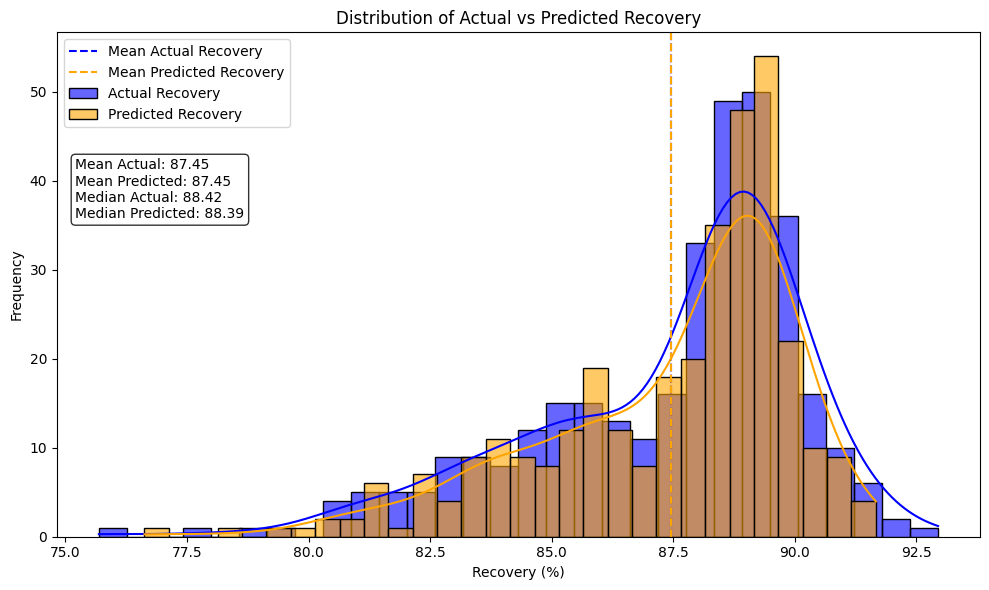

In [132]:
# Plot Distrubution of Actual Recovery and Predicted_Recovery on the same plot with KDE
plt.figure(figsize=(10, 6))
sns.histplot(df["Actual_Recovery"], bins=30, kde=True, color="blue",
			 label="Actual Recovery", alpha=0.6)
sns.histplot(df["Predicted_Recovery"], bins=30, kde=True, color="orange",
			 label="Predicted Recovery", alpha=0.6)
plt.axvline(df["Actual_Recovery"].mean(), color="blue", linestyle="--",
			label="Mean Actual Recovery")
plt.axvline(df["Predicted_Recovery"].mean(), color="orange", linestyle="--",
			label="Mean Predicted Recovery")
plt.title("Distribution of Actual vs Predicted Recovery")
plt.xlabel("Recovery (%)")
plt.ylabel("Frequency")
# Add mean and median values to the plot
mean_actual = df["Actual_Recovery"].mean()
mean_predicted = df["Predicted_Recovery"].mean()
median_actual = df["Actual_Recovery"].median()
median_predicted = df["Predicted_Recovery"].median()
plt.text(0.02, 0.75, f"Mean Actual: {mean_actual:.2f}\n"
					 f"Mean Predicted: {mean_predicted:.2f}\n"
					 f"Median Actual: {median_actual:.2f}\n"
					 f"Median Predicted: {median_predicted:.2f}",
		 transform=plt.gca().transAxes, fontsize=10,
		 verticalalignment='top', bbox=dict(boxstyle='round',
											facecolor='white', alpha=0.8))
plt.legend()
plt.tight_layout()
plt.show()


In [133]:
# --- Sweep values ---
grade_values = [2.0, 2.15, 2.3]
fines_values = [0.70, 0.73, 0.76]
particle_size_list = [65, 73, 85]  # 3 fixed sizes

# --- Cyanide and DO ranges ---
cn_range = np.linspace(100, 500, 25)
do_range = np.linspace(13, 17, 10)
cn_grid, do_grid = np.meshgrid(cn_range, do_range)
cn_flat = cn_grid.flatten()
do_flat = do_grid.flatten()

# --- Loop over each particle size and generate one 3x3 grid per size ---
for particle_size_fixed in particle_size_list:

	# Create 3x3 subplot grid
	fig = make_subplots(
		rows=3, cols=3,
		subplot_titles=[
			f"Grade = {grade} g/t, Fines = {fines}" for grade in grade_values for fines in fines_values
		],
		horizontal_spacing=0.03,
		vertical_spacing=0.07
	)

	# Reduce subplot title size
	for annotation in fig['layout']['annotations']:
		annotation['font'] = dict(size=10)

	# Set axis font sizes
	for i in range(1, 10):
		fig['layout'][f'xaxis{i}'].update(title_font=dict(size=10), tickfont=dict(size=9))
		fig['layout'][f'yaxis{i}'].update(title_font=dict(size=10), tickfont=dict(size=9))

	# Add shared Y-axis label on left
	fig.add_annotation(
		text="Cyanide (ppm)",
		xref="paper", yref="paper",
		x=-0.06, y=0.93,
		showarrow=False,
		textangle=-90,
		font=dict(size=12)
	)
	
	# Add shared Y-axis label on left
	fig.add_annotation(
		text="Cyanide (ppm)",
		xref="paper", yref="paper",
		x=-0.06, y=0.5,
		showarrow=False,
		textangle=-90,
		font=dict(size=12)
	)
	
	# Add shared Y-axis label on left
	fig.add_annotation(
		text="Cyanide (ppm)",
		xref="paper", yref="paper",
		x=-0.06, y=0.07,
		showarrow=False,
		textangle=-90,
		font=dict(size=12)
	)

	# Add X-axis titles to bottom row (xaxis7–9)
	for i in range(7, 10):
		fig['layout'][f'xaxis{i}']['title'] = "Dissolved Oxygen (ppm)"

	# Loop over 3×3 combinations of (grade, fines)
	for i, grade in enumerate(grade_values):
		for j, fines in enumerate(fines_values):
			row = i + 1
			col = j + 1
			grade_x_fines = grade * fines

			# Build input DataFrame
			df_grid = pd.DataFrame({
				"Grade_x_Fines": grade_x_fines,
				"Particle_Size": particle_size_fixed,
				"Dissolved_Oxygen": do_flat,
				"CN_Concentration": cn_flat
			})

			df_grid["Predicted_Recovery"] = model.predict(df_grid)

			# Pivot to heatmap matrix
			heatmap_df = df_grid.pivot(index="CN_Concentration",
							  columns="Dissolved_Oxygen", values="Predicted_Recovery")
			heatmap_df = heatmap_df.reindex(index=np.sort(cn_range), columns=np.sort(do_range))

			# Add heatmap to subplot
			fig.add_trace(
				go.Heatmap(
					z=heatmap_df.values,
					x=np.sort(do_range),
					y=np.sort(cn_range),
					coloraxis="coloraxis"
				),
				row=row, col=col
			)

	# Update layout (shared colorbar + reversed Y-axis)
	fig.update_layout(
		title=dict(
			text=f"Recovery Heatmaps (Fixed Particle Size = {particle_size_fixed} µm)",
			font=dict(size=20), x=0.5, y=0.95, xanchor='center', yanchor='top'
		),
		width=1000,
		height=1000,
		coloraxis=dict(
			colorscale="YlOrRd",
			colorbar=dict(
				title="Recovery (%)",
				thickness=15,
				len=0.8,
				y=0.5,
				yanchor='middle',
				x=1.02,
				xanchor='left'
			)
		),
		showlegend=False
	)

	# Set font size for all x and y axis titles and tick labels
	fig.update_layout({
		f"xaxis{i}": dict(title_font=dict(size=12), tickfont=dict(size=9))
		for i in range(1, 10)
	})
	fig.update_layout({
		f"yaxis{i}": dict(title_font=dict(size=12), tickfont=dict(size=9))
		for i in range(1, 10)
	})

	fig.show()


In [134]:
def colour_by_deviation(actuals, optimised, tolerance_1=0.10, tolerance_2=0.20):
	colours = []
	for act, opt in zip(actuals, optimised):
		if abs(act - opt) <= tolerance_1 * opt:
			colours.append("green")
		elif abs(act - opt) <= tolerance_2 * opt:
			colours.append("orange")
		else:
			colours.append("red")
	return colours

# --- Define window ---
start_date = pd.to_datetime("2024-09-15")
window_days = 7
end_date = start_date + timedelta(days=window_days)

# --- Filter ---
df_window = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)].copy()

# Convert to strings for display on x-axis
days = df_window["Date"].dt.strftime("%a %d-%b")

# Pull actual values
cn_actual = df_window["CN_Concentration"].tolist()
do_actual = df_window["Dissolved_Oxygen"].tolist()
recovery_actual = df_window["Actual_Recovery"].tolist()

# Pull optimised values (these must exist in your DataFrame)
cn_optimised = df_window["Optimal_CN"].tolist()
do_optimised = df_window["Optimal_DO"].tolist()
recovery_optimised = df_window["Optimal_Recovery"].tolist()

# Colour logic for CN and DO (looser)
def colour_by_deviation_standard(actuals, optimised, tolerance_1=0.10, tolerance_2=0.20):
	colours = []
	for act, opt in zip(actuals, optimised):
		if abs(act - opt) <= tolerance_1 * opt:
			colours.append("green")
		elif abs(act - opt) <= tolerance_2 * opt:
			colours.append("orange")
		else:
			colours.append("red")
	return colours

def colour_by_value_impact(value_deltas, green_threshold=2000, orange_threshold=5000):
	colours = []
	for delta in value_deltas:
		if delta <= green_threshold:
			colours.append("green")
		elif delta <= orange_threshold:
			colours.append("orange")
		else:
			colours.append("red")
	return colours

# Create subplot grid
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.1,
					subplot_titles=("Cyanide Dosage (ppm)", "Dissolved Oxygen (ppm)", "Gold Recovery (%)"))

# CN Dosage
fig.add_trace(go.Bar(
	x=days,
	y=cn_actual,
	marker_color=colour_by_deviation_standard(cn_actual, cn_optimised),
	text=[f"A: {int(val)} ppm<br>O: {int(opt)} ppm" for val, opt in zip(cn_actual, cn_optimised)],
	hoverinfo='text',
	name="CN Dosage",
	textangle=0,
	textposition='inside',
	insidetextanchor='end'
), row=1, col=1)

# DO
fig.add_trace(go.Bar(
	x=days,
	y=do_actual,
	marker_color=colour_by_deviation_standard(recovery_actual, recovery_optimised),
	text=[f"A: {int(val)} ppm<br>O: {int(opt)} ppm" for val, opt in zip(do_actual, do_optimised)],
	hoverinfo='text',
	name="DO Level",
	textangle=0,
	textposition='inside',
	insidetextanchor='end'
), row=2, col=1)

# Recovery
recovery_value_loss = (
	df_window["Optimal_Net_Value_USD_t"] - (df_window["Actual_Net_Value_USD"] /
										 df_window["Tonnes_Processed"])
	).tolist()

fig.add_trace(go.Bar(
	x=days,
	y=recovery_actual,
	marker_color=colour_by_value_impact(recovery_value_loss),
	text=[f"{int(val)}%<br>Δ ${int(delta):,}" for val, delta in zip(recovery_actual, recovery_value_loss)],
	hoverinfo='text',
	name="Recovery",
	textfont=dict(size=12, color='white'),
	textangle=0,
	textposition='inside',
	insidetextanchor='end'
), row=3, col=1)


# Layout
fig.update_layout(
	height=850,
	title_text="Weekly Performance vs Optimised Targets (Colour Coded)",
	showlegend=False
)

fig.show()

# # Print actual vs optimised recovery
# for day, act, opt in zip(days, recovery_actual, recovery_optimised):
# 	print(f"{day}: Actual Recovery = {act:.1f}%, Optimised Recovery = {opt:.1f}% "
# 		  f"({('OK' if abs(act - opt) <= 1 else 'Check')})")
	
# # Print Optimal_Net_Value_USD and Actual_Net_Value_USD_t
# for day, act, opt in zip(days, (df_window["Actual_Net_Value_USD"] / df_window["Tonnes_Processed"]), df_window["Optimal_Net_Value_USD_t"]):
# 	print(f"{day}: Actual Net Value = ${act:,.2f}, Optimised Net Value = ${opt:,.2f}, Grade = {df_window['Grade_x_Fines'].iloc[0]:.2f} g/t "
# 	   	  f"Tonnes Processed = {df_window['Tonnes_Processed'].iloc[0]:,.0f} t, "
# 		  f"({('OK' if act >= opt else 'Check')})")
	
# Print Optimal_Net_Value_USD, Optimised Recovery, Grade Tonnes Processed, CN and DO
for day, act, opt_value, opt_recovery, grade, tonnes, cn, sol_mass, do in zip(
	days, df_window["Actual_Net_Value_USD"], df_window["Optimal_Net_Value_USD_t"], df_window["Optimal_Recovery"],
	df_window["Grade_x_Fines"], df_window["Tonnes_Processed"],
	df_window["Optimal_CN"], df_window["Solution_Mass_Kg"], df_window["Optimal_DO"]
):
	print(f"{day}: NV = ${int(opt_value)}, "
		  f"Act = {int(act / tonnes)} "
		  f"CNV = {(opt_recovery / 100 * grade * tonnes)} "
		  f"A = {(opt_recovery / 100 * grade * tonnes)} "
		#   f"CNV = {((opt_recovery / 100 * grade * tonnes) - (cn * sol_mass / 1000000 * tonnes)) * NACN_PRICE_USD_PER_KG} "
		  f"Rec. = {opt_recovery:.1f}%, "
		  f"Grade = {grade:.2f} g/t, t = {tonnes:,.0f} t, "
		  f"CN = {cn:.1f} ppm, DO = {do:.1f} ppm")

Sun 15-Sep: NV = $116, Act = 115 CNV = 2315.6879693387323 A = 2315.6879693387323 Rec. = 87.2%, Grade = 1.05 g/t, t = 2,517 t, CN = 100.0 ppm, DO = 13.0 ppm
Mon 16-Sep: NV = $124, Act = 123 CNV = 2582.8943812927646 A = 2582.8943812927646 Rec. = 88.1%, Grade = 1.20 g/t, t = 2,447 t, CN = 190.0 ppm, DO = 14.0 ppm
Tue 17-Sep: NV = $141, Act = 139 CNV = 2877.537718015708 A = 2877.537718015708 Rec. = 88.8%, Grade = 1.29 g/t, t = 2,506 t, CN = 190.0 ppm, DO = 14.0 ppm
Wed 18-Sep: NV = $118, Act = 118 CNV = 2234.3946240450723 A = 2234.3946240450723 Rec. = 87.8%, Grade = 1.01 g/t, t = 2,521 t, CN = 100.0 ppm, DO = 13.0 ppm
Thu 19-Sep: NV = $146, Act = 144 CNV = 2918.6672468761963 A = 2918.6672468761963 Rec. = 88.8%, Grade = 1.30 g/t, t = 2,533 t, CN = 190.0 ppm, DO = 14.0 ppm
Fri 20-Sep: NV = $157, Act = 155 CNV = 3057.87493455935 A = 3057.87493455935 Rec. = 88.9%, Grade = 1.37 g/t, t = 2,508 t, CN = 190.0 ppm, DO = 14.0 ppm
Sat 21-Sep: NV = $200, Act = 197 CNV = 3602.3519443736004 A = 3602.351

In [135]:
df_temp = df.copy()
# df_temp['New_Slurry_Mass'] = df_temp['Tonnes_Processed'] * 1000  # Convert tonnes to kg
df_temp['Actual_CN_Cost_New'] = (df_temp['NaCN_Used_Kg'] * NACN_PRICE_USD_PER_KG)
df_temp['Actual_DO_Cost_New'] = df_temp['Dissolved_Oxygen'] * df_temp['Solution_Mass_Kg'] / 1e6 * DO_PRICE_USD_PER_KG
df_temp['Actual_Net_Value'] = (
	df_temp['Actual_Gold_Revenue'] - df_temp['Actual_CN_Cost_New'] - df_temp['Actual_DO_Cost_New']
)
df_temp['Actual_Net_Value_t'] = df_temp['Actual_Net_Value'] / df_temp['Tonnes_Processed']
df_temp[['Actual_Net_Value', 'Actual_Net_Value_t', 'Optimal_Net_Value_USD_t']].describe()




,Actual_Net_Value,Actual_Net_Value_t,Optimal_Net_Value_USD_t
count,334.000000,334.000000,334.000000
mean,400098.330571,168.947801,173.193850
std,116121.327786,41.082209,41.099184
min,106525.713741,80.004789,86.121467
25%,319518.476649,137.002958,140.391568
50%,407584.235737,169.058479,173.333306
75%,480522.513995,195.566554,198.439806
max,738329.396329,288.120708,289.035918
